In [ ]:
# 0) Imports
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.rms import (
    generate_wave,
    add_noise,
    add_dc,
    rms_manual,
    rolling_rms,
 )

# parameters
fs       = 5_000
f_signal = 50
duration = 0.2
Vpk      = 325.0
Vdc      = 20.0
sigma    = 0.05 * Vpk
window_sec = 0.05          # 50 ms rolling RMS window

# 2) Build the signals (using the library)
t, x_clean = generate_wave(Vpk, f_signal, fs, duration)
x_noise    = add_noise(x_clean, sigma, rng=np.random.default_rng(42))
x_offset   = add_dc(x_clean, Vdc)
x_noise_offset = add_noise(x_offset, sigma, rng=np.random.default_rng(42))

# 3) Static RMS values
rms_clean        = rms_manual(x_clean)
rms_noise        = rms_manual(x_noise)
rms_offset       = rms_manual(x_offset)
rms_noise_offset = rms_manual(x_noise_offset)

print("=== RMS values (V) ===")
print(f"Clean sine                : {rms_clean:8.3f}")
print(f"Clean + noise             : {rms_noise:8.3f}")
print(f"Clean + DC offset         : {rms_offset:8.3f}")
print(f"Noise + DC offset         : {rms_noise_offset:8.3f}")

# 4) Verify textbook relation (same as in your short block)
rms_theoretical = Vpk / np.sqrt(2)
print("\nTheoretical RMS (Vpk/sqrt(2)) = {:.3f}".format(rms_theoretical))
print("Difference (clean - theory) = {:.3e}".format(rms_clean - rms_theoretical))

# 5) Rolling RMS (using the library)
t_roll, rms_roll = rolling_rms(x_noise, fs, window_sec)

     



=== RMS values (V) ===
Clean sine                :  229.810
Clean + noise             :  230.370
Clean + DC offset         :  230.678
Noise + DC offset         :  231.196

Theoretical RMS (Vpk/sqrt(2)) = 229.810
Difference (clean - theory) = 2.842e-14


: 

In [2]:
# Install required packages into the active notebook kernel
%pip install numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


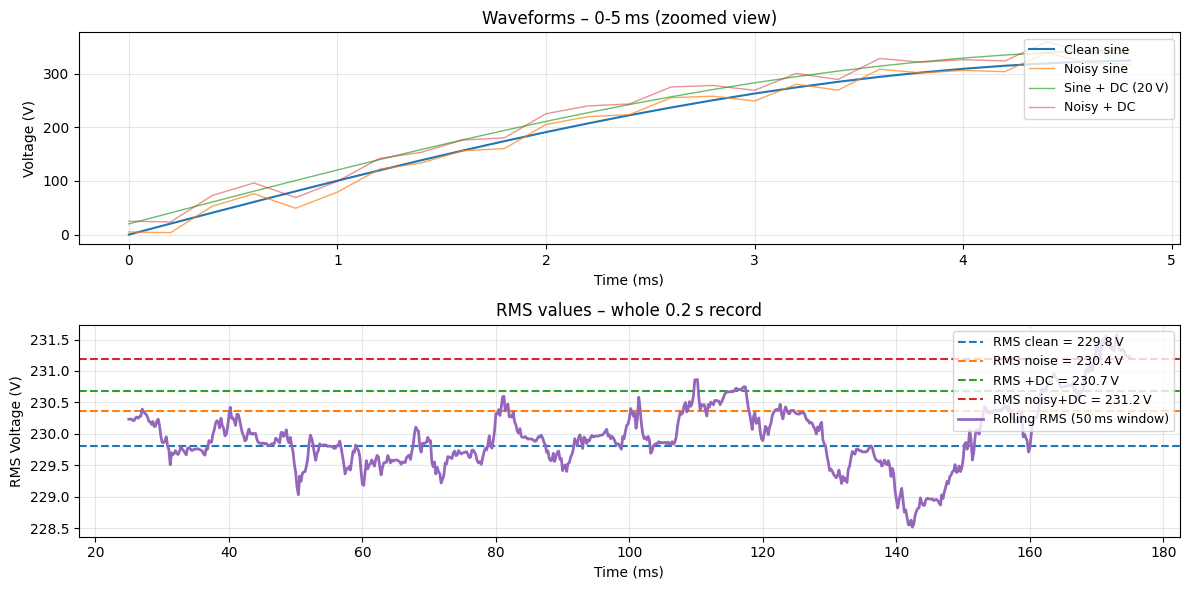

In [3]:
plt.figure(figsize=(12, 6))

# ---------- Top panel – raw waveforms (first 5 ms) ----------
zoom_ms      = 5                              # how many milliseconds to display
zoom_samples = int(zoom_ms * 1e-3 * fs)        # number of samples in that window

ax1 = plt.subplot(2, 1, 1)                    # 2 rows, 1 column, panel 1
ax1.plot(t[:zoom_samples] * 1e3, x_clean[:zoom_samples],
         label='Clean sine', lw=1.5)
ax1.plot(t[:zoom_samples] * 1e3, x_noise[:zoom_samples],
         label='Noisy sine', lw=1, alpha=0.7)
ax1.plot(t[:zoom_samples] * 1e3, x_offset[:zoom_samples],
         label='Sine + DC (20 V)', lw=1, alpha=0.7)
ax1.plot(t[:zoom_samples] * 1e3, x_noise_offset[:zoom_samples],
         label='Noisy + DC', lw=1, alpha=0.5)

ax1.set_xlabel('Time (ms)')
ax1.set_ylabel('Voltage (V)')
ax1.set_title('Waveforms – 0‑5 ms (zoomed view)')
ax1.grid(alpha=0.3)
ax1.legend(loc='upper right', fontsize=9)

# ---------- Bottom panel – static RMS lines + rolling RMS ----------
ax2 = plt.subplot(2, 1, 2)                    # panel 2
ax2.axhline(rms_clean,        color='tab:blue',   ls='--',
            label=f'RMS clean = {rms_clean:.1f} V')
ax2.axhline(rms_noise,        color='tab:orange', ls='--',
            label=f'RMS noise = {rms_noise:.1f} V')
ax2.axhline(rms_offset,       color='tab:green',  ls='--',
            label=f'RMS +DC = {rms_offset:.1f} V')
ax2.axhline(rms_noise_offset, color='tab:red',    ls='--',
            label=f'RMS noisy+DC = {rms_noise_offset:.1f} V')

# Rolling RMS curve (computed on the *noisy* signal)
ax2.plot(t_roll * 1e3, rms_roll,
         color='tab:purple', lw=2,
         label='Rolling RMS (50 ms window)')

ax2.set_xlabel('Time (ms)')
ax2.set_ylabel('RMS Voltage (V)')
ax2.set_title('RMS values – whole 0.2 s record')
ax2.grid(alpha=0.3)
ax2.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()      